# Weak-lensing galaxy shape catalogue validation 1

## PSF leakage

Contents
- Linear fit PSF leakage
- Scale-dependent PSF leakage alpha
- Cross-correlation function xi_sys

> **_NOTE:_** Before running this notebook, set kernel to `main_set.ipynb'

In [69]:
%matplotlib inline

import os
from uncertainties import ufloat

In [82]:
from sp_validation.survey import *
from sp_validation.util import *
from sp_validation.basic import *
from sp_validation.plots import *
from sp_validation.galaxy import *
from sp_validation.cat import *
from sp_validation.correlation import *
from sp_validation.cosmology import *

### Linear fit
Fit galaxy ellipticity as function of (binned) PSF ellipticity.

In [71]:
n_bin = 30

colors = ['b', 'r']
ylabel = r'$e_{1,2}^{\rm gal}$'
mlabel = ['m_1', 'm_2']

xlabel_arr = [r'$e_{1}^{\rm PSF}$', r'$e_{2}^{\rm PSF}$', r'$\mathrm{FWHM}^{\rm PSF}$ [arcsec]']

#### ngmix

ngmix:


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:04<00:00,  6.75it/s]


$e_{1}^{\rm PSF}$: m_1=0.007±0.012
$e_{1}^{\rm PSF}$: m_2=-0.005±0.012


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:04<00:00,  7.24it/s]


$e_{2}^{\rm PSF}$: m_1=0.038±0.012
$e_{2}^{\rm PSF}$: m_2=0.003±0.012


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:03<00:00,  8.01it/s]


$\mathrm{FWHM}^{\rm PSF}$ [arcsec]: m_1=0.0068±0.0048
$\mathrm{FWHM}^{\rm PSF}$ [arcsec]: m_2=-0.0045±0.0049


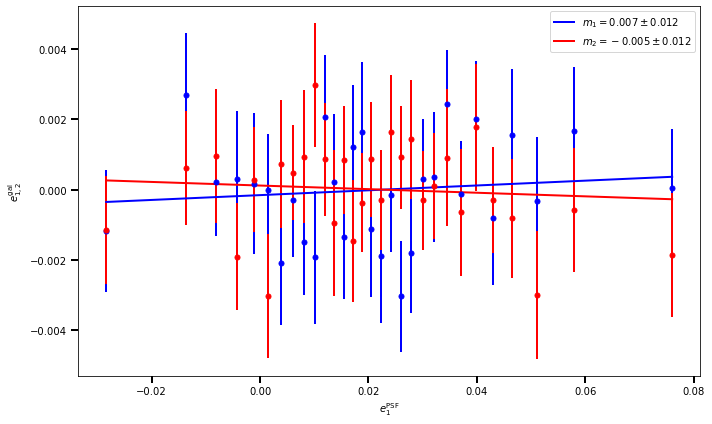

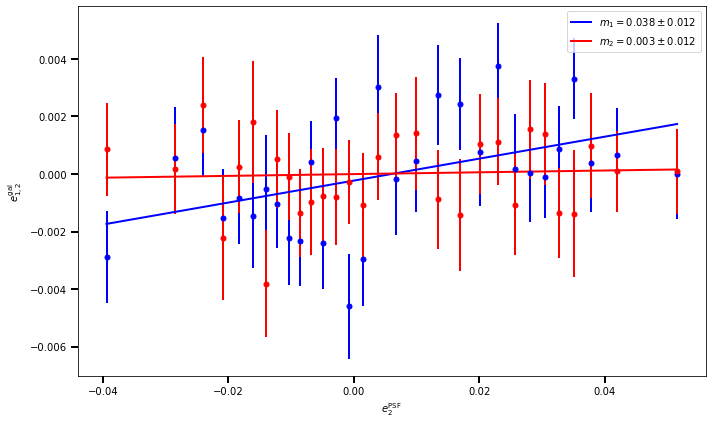

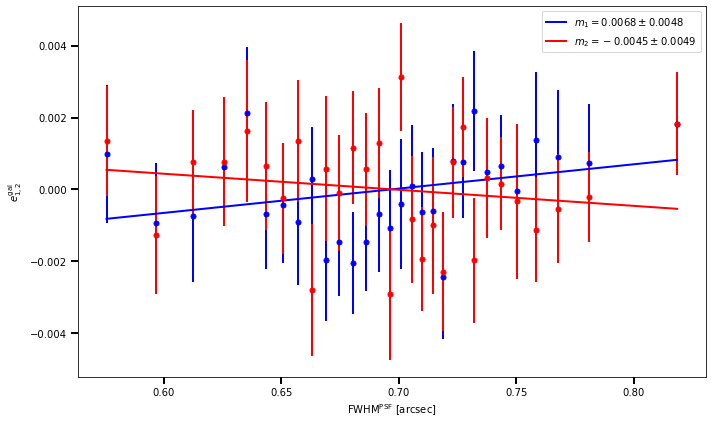

In [72]:
plot_dir_leakage = f'{plot_dir}/psf_leak_ngmix'
print_stats('ngmix:', stats_file, verbose=verbose)

e1 = g_corr_ngmix[0] - c_ngmix[0]
e2 = g_corr_ngmix[1] - c_ngmix[1]
e = [e1, e2]
weights = w_ngmix

x_arr = [
    dd['NGMIX_ELL_PSFo_NOSHEAR'][:,0][m_gal_ngmix][mask],
    dd['NGMIX_ELL_PSFo_NOSHEAR'][:,1][m_gal_ngmix][mask],
    T_to_fwhm(dd['NGMIX_T_PSFo_NOSHEAR'][m_gal_ngmix][mask])
]
out_name_arr = [
    'PSF_e1_vs_e_gal',
    'PSF_e2_vs_e_gal',
    'PSF_size_vs_e_gal'
]
out_path_arr = [f'{plot_dir_leakage}/{name}' for name in out_name_arr]
affine_corr_n(
    x_arr,
    e,
    xlabel_arr,
    ylabel,
    mlabel=mlabel,
    weights=weights,
    n_bin=n_bin,
    out_path_arr=out_path_arr,
    colors=colors,
    stats_file=stats_file,
    verbose=True
)

In [73]:
#### galsim

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 39.82it/s]


$e_{1}^{\rm PSF}$: m_1=-0.263±0.062
$e_{1}^{\rm PSF}$: m_2=-0.048±0.035


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 40.12it/s]


$e_{2}^{\rm PSF}$: m_1=0.006±0.058
$e_{2}^{\rm PSF}$: m_2=-0.134±0.033


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 38.68it/s]


$\mathrm{FWHM}^{\rm PSF}$ [arcsec]: m_1=0.080±0.024
$\mathrm{FWHM}^{\rm PSF}$ [arcsec]: m_2=0.019±0.014


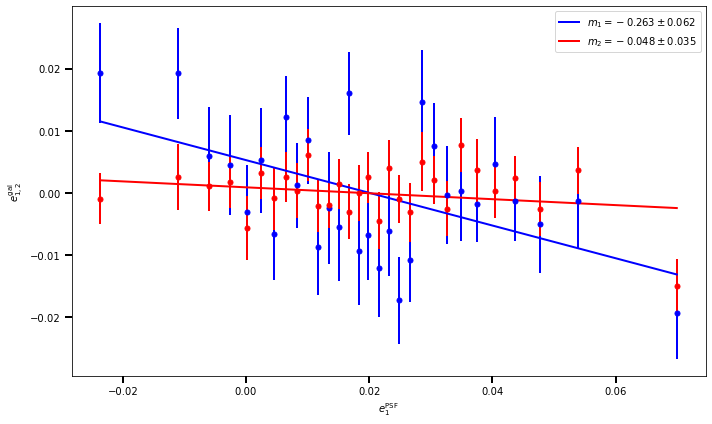

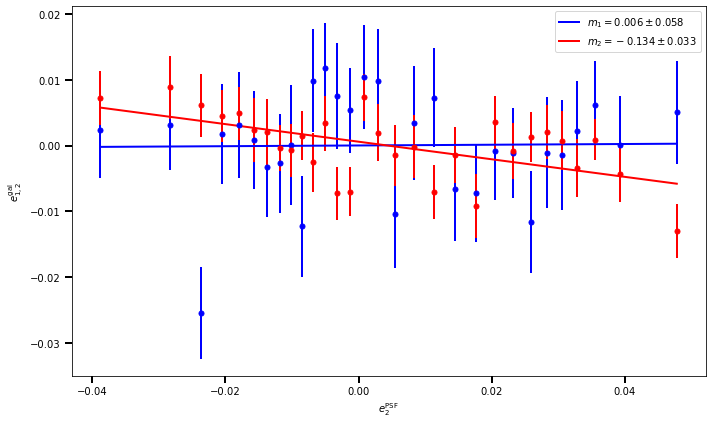

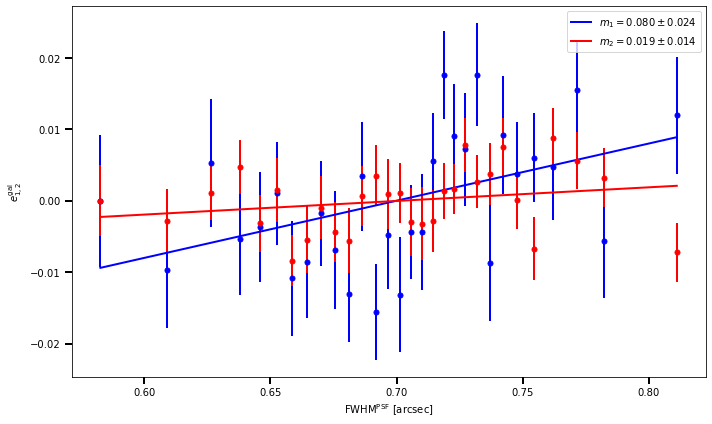

In [74]:
plot_dir_leakage = '{}/psf_leak_galsim'.format(plot_dir)

e1 = g_corr_galsim[0] - c_galsim[0]
e2 = g_corr_galsim[1] - c_galsim[1]
e = [e1, e2]
weights = None

x_arr = [
    dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,0][m_gal_galsim][mask_galsim],
    dd['GALSIM_PSF_ELL_ORIGINAL_PSF'][:,1][m_gal_galsim][mask_galsim],
    sigma_to_fwhm(dd['GALSIM_PSF_SIGMA_ORIGINAL_PSF'][m_gal_galsim][mask_galsim], pixel_size=pixel_size)
]
out_name_arr = [
    'PSF_e1_vs_e_gal',
    'PSF_e2_vs_e_gal',
    'PSF_size_vs_e_gal'
]
out_path_arr = [f'{plot_dir_leakage}/{name}' for name in out_name_arr]
affine_corr_n(
    x_arr,
    e,
    xlabel_arr,
    ylabel,
    mlabel=mlabel,
    weights=weights,
    n_bin=n_bin,
    out_path_arr=out_path_arr,
    colors=colors,
    stats_file=stats_file,
    verbose=True
)

### Scale-dependent leakage
Compute scale-dependent leakage $\alpha(\theta)$ from cross-correlations betwen galaxy and PSF ellipticities,
$$
    \alpha(\theta) = \frac{\xi_{+}^{\rm gp}(\theta) - \langle e_{\rm gal} \rangle^{*} \langle e_{\rm PSF} \rangle}{\xi_{+}^{\rm pp}(\theta) - |\langle e_{\rm PSF} \rangle|^{2}}
$$
With g = galaxy and p = PSF.

#### ngmix

In [83]:
print_stats('ngmix:', stats_file, verbose=verbose)

e1_gal = g_corr_ngmix[0] - c_ngmix[0]
e2_gal = g_corr_ngmix[1] - c_ngmix[1]
weights = w_ngmix
e1_star = g_star_psf_ngmix[0]
e2_star = g_star_psf_ngmix[1]

# Correlation functions
r_corr_gp_ngmix, r_corr_pp_ngmix = correlation_12_22(ra_ngmix, dec_ngmix, e1_gal, e2_gal, weights,
                                                     ra_star_ngmix, dec_star_ngmix, e1_star, e2_star)

# Leakage
alpha_leak_ngmix, sig_alpha_leak_ngmix = alpha(r_corr_gp_ngmix, r_corr_pp_ngmix,
                                               e1_gal, e2_gal, weights, e1_star, e2_star)

ngmix:


In [84]:
alpha_leak_mean_ngmix = transform_nan(np.average(alpha_leak_ngmix, weights=1/sig_alpha_leak_ngmix**2))
print_stats('Weighted average alpha = {:.3g}'.format(alpha_leak_mean_ngmix), stats_file, verbose=verbose)

Weighted average alpha = 0.0367


In [85]:
plot_dir_leakage = '{}/psf_leak_ngmix'.format(plot_dir)

theta = [r_corr_gp_ngmix.meanr]
alpha_theta = [alpha_leak_ngmix]
yerr = [sig_alpha_leak_ngmix]
xlabel = r'$\theta$ [arcmin]'
ylabel = r'$\alpha(\theta)$'
title = 'ngmix'
out_path = f'{plot_dir_leakage}/alpha_leakage_ngmix.png'
try:
    ylim  = leakage_alpha_ylim
except:
    ylim = None

plot_data_1d(theta, alpha, yerr, title, xlabel, ylabel, out_path, xlog=True, ylim=ylim)

TypeError: 'function' object is not subscriptable

<Figure size 1080x720 with 0 Axes>

#### galsim

In [ ]:
print_stats('galsim:', stats_file, verbose=verbose)

e1_gal = g_corr_galsim[0] - c_galsim[0]
e2_gal = g_corr_galsim[1] - c_galsim[1]
weights = w_galsim
e1_star = g_star_psf_galsim[0]
e2_star = g_star_psf_galsim[1]

# Correlation functions
r_corr_gp_galsim, r_corr_pp_galsim = correlation_12_22(ra_galsim, dec_galsim, e1_gal, e2_gal, weights,
                                                       ra_star_galsim, dec_star_galsim, e1_star, e2_star)

# Leakage
alpha_leak_galsim, sig_alpha_leak_galsim = alpha(r_corr_gp_galsim, r_corr_pp_galsim,
                                                 e1_gal, e2_gal, weights, e1_star, e2_star)

alpha_leak_mean_galsim = np.average(alpha_leak_galsim, weights=1/sig_alpha_leak_galsim**2)
print_stats('Weighted average alpha = {:.3g}'.format(alpha_leak_mean_galsim), stats_file, verbose=verbose)

In [86]:
plot_dir_leakage = '{}/psf_leak_galsim'.format(plot_dir)

theta = [r_corr_gp_galsim.meanr]
alpha_theta = [alpha_leak_galsim]
yerr = [sig_alpha_leak_galsim]
xlabel = r'$\theta$ [arcmin]'
ylabel = r'$\alpha(\theta)$'
title = 'galsim'
out_path = '{}/alpha_leakage_galsim.png'.format(plot_dir_leakage)
try:
    ylim  = leakage_alpha_ylim
except:
    ylim = None

plot_data_1d(theta, alpha_theta, yerr, title, xlabel, ylabel, out_path, xlog=True, ylim=ylim)

NameError: name 'alpha_leak_galsim' is not defined

### Cross-correlation PSF leakage
Compute $\xi^{\rm sys}$, the normalised cross-correlation function of galaxy and star ellipticities:
$$
\xi^{\rm sys}(\theta) = \frac{\left( \xi_{\pm}^{\rm gp}(\theta) \right)^2}{\xi_{\pm}^{\rm pp}(\theta)}
$$   
With $g$: galaxy and $p$: PSF.

In [87]:
C_sys_p_ngmix = r_corr_gp_ngmix.xip**2 / r_corr_pp_ngmix.xip
C_sys_m_ngmix = r_corr_gp_ngmix.xim**2 / r_corr_pp_ngmix.xim

C_sys_std_p_ngmix = np.abs(C_sys_p_ngmix) * np.sqrt((((2*r_corr_gp_ngmix.xip**2 * np.sqrt(r_corr_gp_ngmix.varxip))/r_corr_gp_ngmix.xip)/r_corr_gp_ngmix.xip**2.)**2 + (np.sqrt(r_corr_pp_ngmix.varxip)/r_corr_pp_ngmix.xip)**2.)
C_sys_std_m_ngmix = np.abs(C_sys_m_ngmix) * np.sqrt((((2*r_corr_gp_ngmix.xim**2 * np.sqrt(r_corr_gp_ngmix.varxim))/r_corr_gp_ngmix.xim)/r_corr_gp_ngmix.xim**2.)**2 + (np.sqrt(r_corr_pp_ngmix.varxim)/r_corr_pp_ngmix.xim)**2.)

#### Theoretical prediction

In [88]:
# Redshift distribution

nz_base = 'nz.CFHTLenSmatched.W3'
nz_ext = 'txt'
nz_date = '202012'
nz_version = 'v1'
nz_name = '{}_{}_{}.{}'.format(nz_base, nz_date, nz_version, nz_ext)
source = f'vos:cfis/cosmostat/cosmology/redshifts/{nz_name}'
target = f'{data_dir}/{nz_name}'

download(source, target, verbose=True)

z, nz = np.loadtxt(target, unpack=True)

Target file /Users/mkilbing/data_WL/nz.CFHTLenSmatched.W3_202012_v1.txt exists, skipping download.


In [89]:
try:
    xi_p_planck, xi_m_planck = get_theo_xi(r_corr_gp_ngmix.meanr, z, nz, Omega_m=Om, h=h, Omega_b=Ob, sig8=sig8, ns=ns)
except:
    print('Computation of theoretical prediction failed')

/Users/mkilbing/anaconda3/envs/sp_validation/lib/python3.8/site-packages/pyccl/correlations.py:83: CCLWarning: corr_type is deprecated. Use type = GG+
  warnings.warn("corr_type is deprecated. Use type = {}".format(type),
/Users/mkilbing/anaconda3/envs/sp_validation/lib/python3.8/site-packages/pyccl/correlations.py:83: CCLWarning: corr_type is deprecated. Use type = GG-
  warnings.warn("corr_type is deprecated. Use type = {}".format(type),


#### ngmix

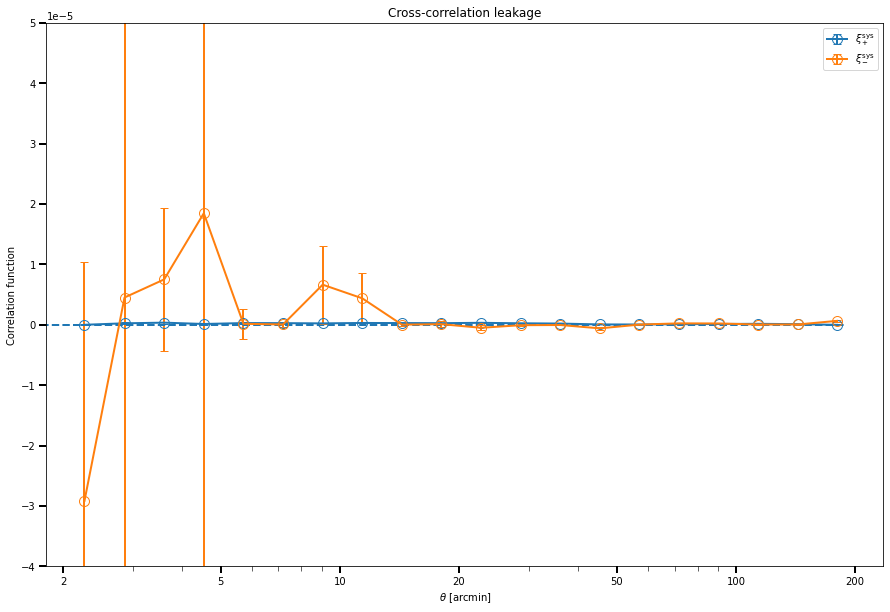

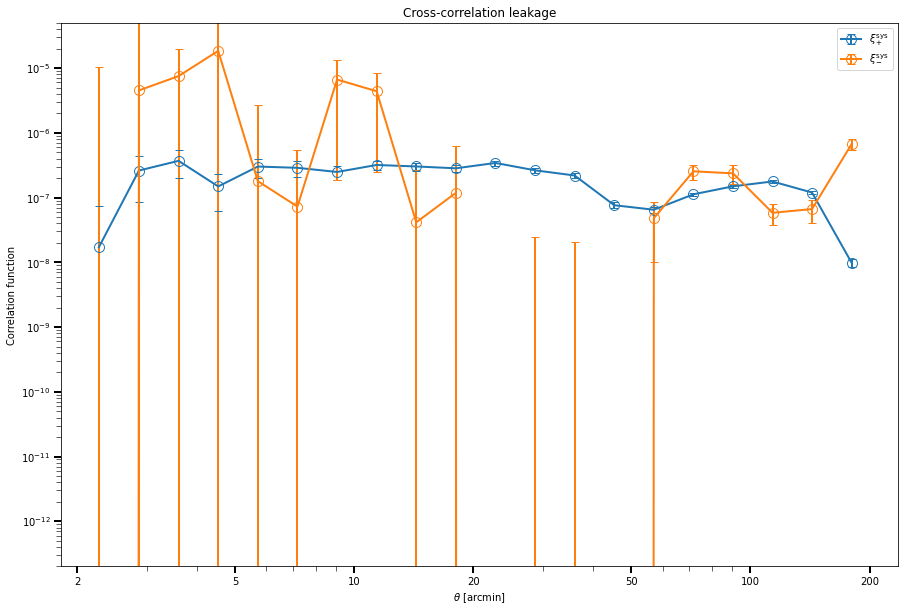

In [91]:
plot_dir_leakage = '{}/psf_leak_ngmix'.format(plot_dir)

theta = [r_corr_gp_ngmix.meanr] * 2
xi = [C_sys_p_ngmix, C_sys_m_ngmix]
yerr = [C_sys_std_p_ngmix, C_sys_std_m_ngmix]
labels = ['$\\xi^{\\rm sys}_+$', '$\\xi^{\\rm sys}_-$']

title = 'Cross-correlation leakage'
xlabel = '$\\theta$ [arcmin]'
ylabel = 'Correlation function'

try:
    ylim = leakage_xi_sys_ylim
except:
    ylim = None
out_path = '{}/xi_sys_ngmix.pdf'.format(plot_dir)
plot_data_1d(theta, xi, yerr, title, xlabel, ylabel, out_path, xlog=True, ylim=ylim, labels=labels)

try:
    ylim = leakage_xi_sys_log_ylim
except:
    ylim = None
out_path = '{}/xi_sys_log_ngmix.pdf'.format(plot_dir)
plot_data_1d(theta, xi, yerr, title, xlabel, ylabel, out_path, xlog=True, ylog=True, ylim=ylim, labels=labels)